In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

In [2]:
DATA_PATH = r"C:\Users\mudav\Downloads\Supermart Grocery Sales - Retail Analytics Dataset.csv"
CLEANED_OUT = "/mnt/data/cleaned_supermart_full.csv"  
SAMPLE_OUT = "/mnt/data/cleaned_supermart_sample.csv"  
plt.rcParams['figure.dpi'] = 120
def print_sep(title):
    print("\n" + "-"*6 + " " + title + " " + "-"*6)

In [3]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Upload or set correct path.")

df = pd.read_csv(DATA_PATH, encoding='utf-8')
print("Loaded dataset shape:", df.shape)
print_sep("Columns & dtypes")
print(df.dtypes)

Loaded dataset shape: (9994, 11)

------ Columns & dtypes ------
Order ID          object
Customer Name     object
Category          object
Sub Category      object
City              object
Order Date        object
Region            object
Sales              int64
Discount         float64
Profit           float64
State             object
dtype: object


In [4]:
print_sep("First 5 rows")
display(df.head())


------ First 5 rows ------


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [5]:
df.columns = [c.strip() for c in df.columns]

In [6]:
date_col_candidates = [c for c in df.columns if 'date' in c.lower() or 'order' in c.lower() and 'date' in c.lower()]
for cand in ["Order Date", "OrderDate", "Date", "order_date"]:
    if cand in df.columns and cand not in date_col_candidates:
        date_col_candidates.append(cand)

date_col = date_col_candidates[0] if date_col_candidates else None

if date_col:
    print_sep(f"Parsing date column: {date_col}")
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=False)
    null_dates = df[date_col].isna().sum()
    print(f"Null / unparsable dates: {null_dates} / {len(df)}")
else:
    print("No date column detected. You can set date_col variable manually.")


------ Parsing date column: Order Date ------
Null / unparsable dates: 5952 / 9994


In [7]:
likely_numeric_names = ["sales", "profit", "discount", "quantity", "qty", "amount", "price", "total"]
num_cols = []
for c in df.columns:
    low = c.lower()
    if any(n in low for n in likely_numeric_names):
        num_cols.append(c)

In [8]:
num_cols += [c for c in df.select_dtypes(include=['int64','float64']).columns if c not in num_cols]
num_cols = list(dict.fromkeys(num_cols))

In [9]:
print_sep("Numeric candidate columns")
print(num_cols)


------ Numeric candidate columns ------
['Sales', 'Discount', 'Profit']


In [10]:
for c in num_cols:
    df[c] = df[c].astype(str).str.replace(r'[^\d\.\-]', '', regex=True).replace('', np.nan)
    df[c] = pd.to_numeric(df[c], errors='coerce')

print_sep("Numeric summary")
display(df[num_cols].describe().T)


------ Numeric summary ------


,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,1496.596158,577.559036,500.00,1000.0000,1498.00,1994.7500,2500.00
Discount,9994.0,0.226817,0.074636,0.10,0.1600,0.23,0.2900,0.35
Profit,9994.0,374.937082,239.932881,25.25,180.0225,320.78,525.6275,1120.95


In [11]:
if date_col:
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['day'] = df[date_col].dt.day
    df['year_month'] = df[date_col].dt.to_period('M').astype(str)
else:
    df['year_month'] = np.nan

In [12]:
sales_col = None
for c in num_cols:
    if c.lower() in ['sales', 'total', 'amount']:
        sales_col = c
        break
if sales_col is None and len(num_cols) > 0:
    sales_col = num_cols[0]

In [13]:
profit_col = next((c for c in num_cols if 'profit' in c.lower()), None)

print_sep("Using columns")
print("Sales column:", sales_col)
print("Profit column:", profit_col)


------ Using columns ------
Sales column: Sales
Profit column: Profit


In [14]:
print_sep("Missing values (top columns)")
miss = df.isna().sum().sort_values(ascending=False)
display(miss.head(20))


------ Missing values (top columns) ------


Order Date       5952
day              5952
month            5952
year             5952
Category            0
Customer Name       0
Order ID            0
Region              0
City                0
Sub Category        0
Sales               0
State               0
Profit              0
Discount            0
year_month          0
dtype: int64

In [15]:
print_sep("Top-level KPIs")
if sales_col:
    total_sales = df[sales_col].sum(skipna=True)
    avg_order_value = df[sales_col].mean(skipna=True)
    print(f"Total Sales = {total_sales:,.2f}")
    print(f"Average order value = {avg_order_value:,.2f}")
else:
    print("Sales column not found; KPIs skipped.")

if profit_col:
    total_profit = df[profit_col].sum(skipna=True)
    print(f"Total Profit = {total_profit:,.2f}")


------ Top-level KPIs ------
Total Sales = 14,956,982.00
Average order value = 1,496.60
Total Profit = 3,747,121.20


In [16]:
cust_col = next((c for c in df.columns if 'customer' in c.lower()), None)
order_col = next((c for c in df.columns if 'order' in c.lower() and 'id' in c.lower()) , None)
if cust_col:
    print("Unique customers:", df[cust_col].nunique())
if order_col:
    print("Unique orders:", df[order_col].nunique())

Unique customers: 50
Unique orders: 9994



------ Monthly sales (head) ------


,year_month,Sales,year_month_dt
0,2015-01,30730,2015-01-01
1,2015-02,38759,2015-02-01
2,2015-03,79758,2015-03-01
3,2015-04,110584,2015-04-01
4,2015-05,66499,2015-05-01


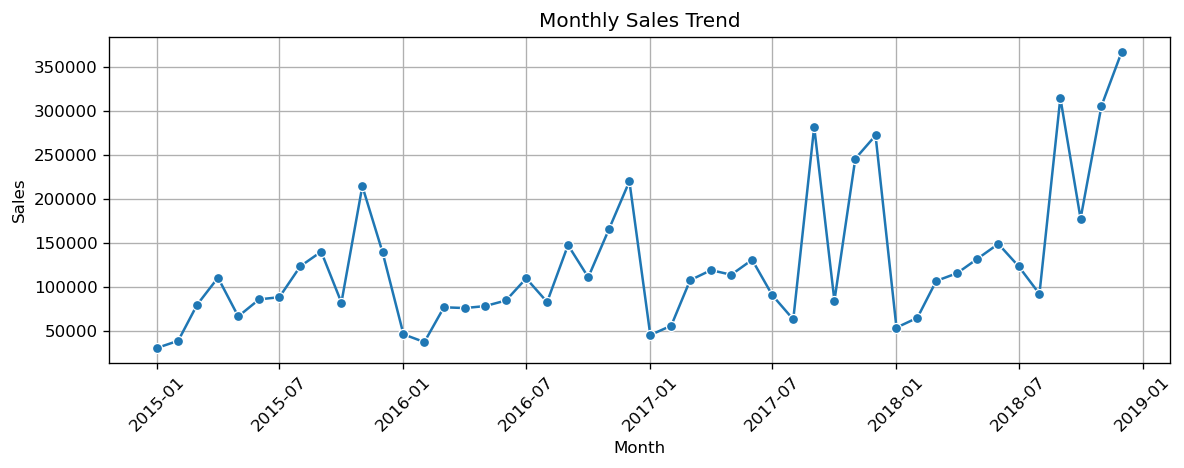

In [18]:
if date_col and sales_col:
    monthly = df.groupby('year_month')[sales_col].sum().reset_index().sort_values('year_month')
    monthly['year_month_dt'] = pd.to_datetime(monthly['year_month'] )
    print_sep("Monthly sales (head)")
    display(monthly.head())

    plt.figure(figsize=(10,4))
    sns.lineplot(data=monthly, x='year_month_dt', y=sales_col, marker='o')
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel(sales_col)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


------ Top products by sales ------


Sub Category
Health Drinks        1051439
Soft Drinks          1033874
Cookies               768213
Breads & Buns         742586
Noodles               735435
Chocolates            733898
Masalas               697480
Cakes                 685612
Biscuits              684083
Spices                672876
Edible Oil & Ghee     668086
Mutton                611200
Eggs                  575156
Fish                  560548
Organic Staples       558929
Name: Sales, dtype: int64

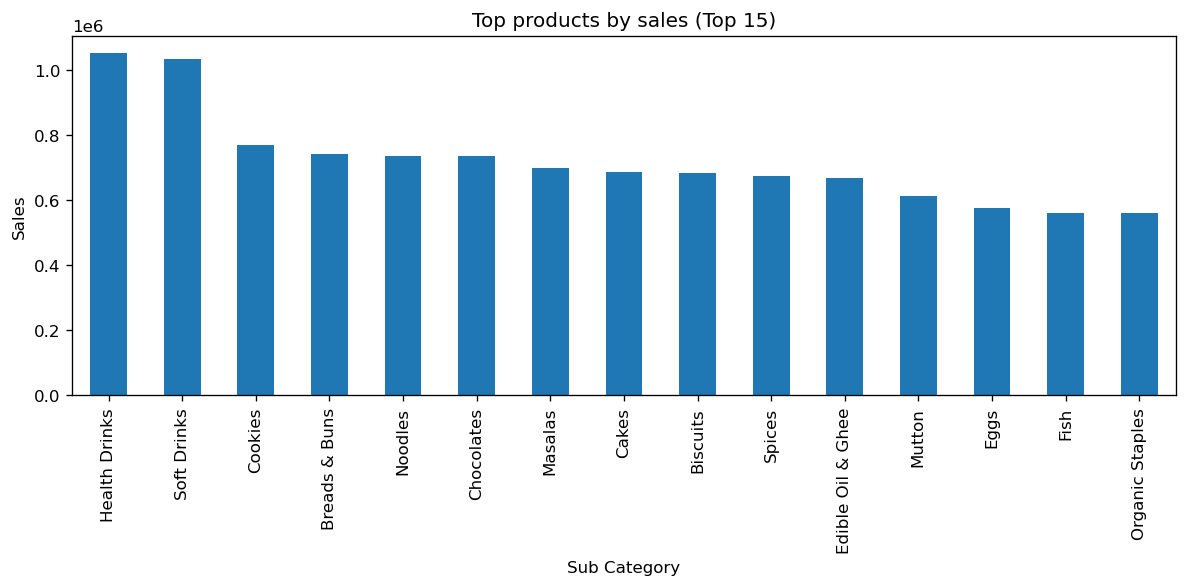

In [19]:
prod_col = next((c for c in df.columns if 'product' in c.lower() or 'item' in c.lower() or 'sub category' in c.lower()), None)
if prod_col and sales_col:
    top_products = df.groupby(prod_col)[sales_col].sum().sort_values(ascending=False).head(15)
    print_sep("Top products by sales")
    display(top_products)
    plt.figure(figsize=(10,5))
    top_products.plot(kind='bar')
    plt.ylabel(sales_col)
    plt.title("Top products by sales (Top 15)")
    plt.tight_layout()
    plt.show()


------ Top regions by sales (City) ------


City
Kanyakumari    706764
Vellore        676550
Bodi           667177
Tirunelveli    659812
Perambalur     659738
Salem          657093
Pudukottai     653179
Tenkasi        643652
Karur          642273
Krishnagiri    637273
Chennai        634963
Coimbatore     634748
Name: Sales, dtype: int64

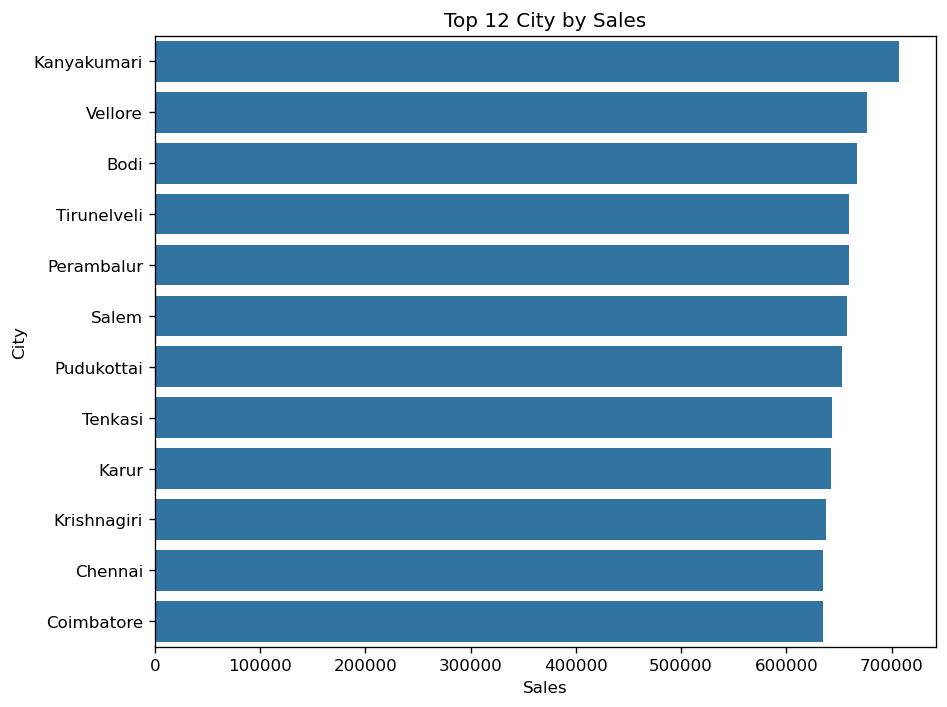

In [20]:
region_col = next((c for c in df.columns if any(x in c.lower() for x in ['city','state','region','location'])), None)
if region_col and sales_col:
    region_sales = df.groupby(region_col)[sales_col].sum().sort_values(ascending=False).head(12)
    print_sep(f"Top regions by sales ({region_col})")
    display(region_sales)
    plt.figure(figsize=(8,6))
    sns.barplot(x=region_sales.values, y=region_sales.index)
    plt.xlabel(sales_col)
    plt.ylabel(region_col)
    plt.title(f"Top {len(region_sales)} {region_col} by Sales")
    plt.tight_layout()
    plt.show()

In [21]:
qty_col = next((c for c in num_cols if 'qty' in c.lower() or 'quantity' in c.lower()), None)
if qty_col and prod_col:
    top_qty = df.groupby(prod_col)[qty_col].sum().sort_values(ascending=False).head(15)
    print_sep("Top items by quantity sold")
    display(top_qty)
    plt.figure(figsize=(10,5))
    top_qty.plot(kind='bar')
    plt.ylabel(qty_col)
    plt.title("Top items by quantity")
    plt.tight_layout()
    plt.show()


------ Correlation matrix (numeric columns) ------


,Sales,Discount,Profit
Sales,1.000000,-0.005512,0.605349
Discount,-0.005512,1.000000,0.000017
Profit,0.605349,0.000017,1.000000


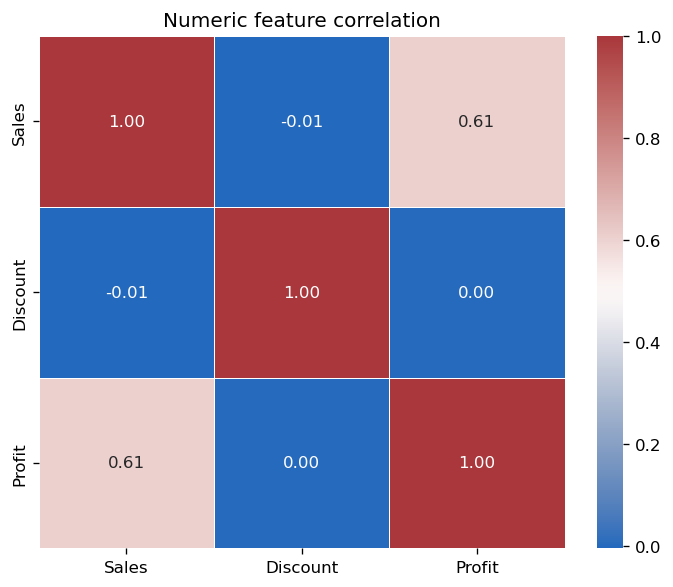

In [22]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    print_sep("Correlation matrix (numeric columns)")
    display(corr)
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", linewidths=0.5)
    plt.title("Numeric feature correlation")
    plt.tight_layout()
    plt.show()

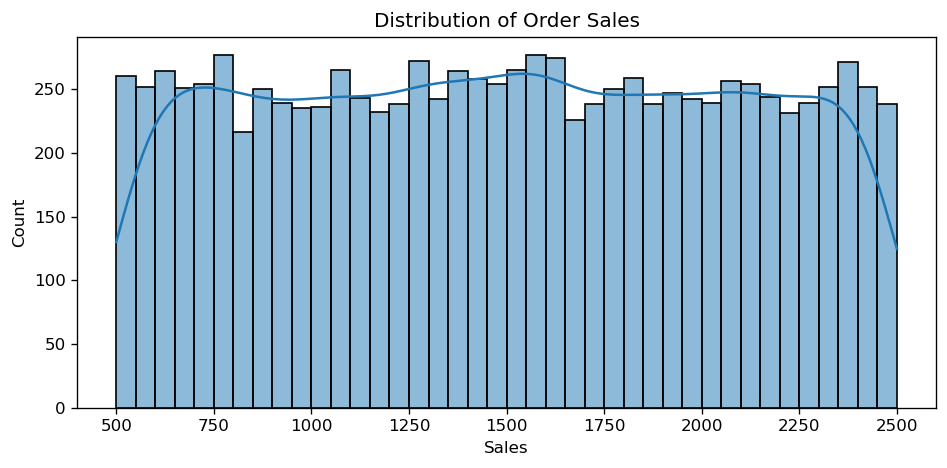

In [23]:
if sales_col:
    plt.figure(figsize=(8,4))
    sns.histplot(df[sales_col].dropna(), bins=40, kde=True)
    plt.title("Distribution of Order Sales")
    plt.xlabel(sales_col)
    plt.tight_layout()
    plt.show()

In [33]:
if cust_col and date_col and sales_col:
    print_sep("Computing RFM (simple)")
    snapshot_date = df[date_col].max() + pd.Timedelta(days=1)
    agg_dict = {
        date_col: lambda x: (snapshot_date - x.max()).days,
        sales_col: 'sum'
    }
    if order_col:
        agg_dict[order_col] = 'nunique'
    else:
        agg_dict[date_col] = 'nunique'
    
    rfm = df.groupby(cust_col).agg(agg_dict).reset_index()
    rfm.columns = [cust_col, 'Recency', 'Frequency', 'Monetary']  # adjust names
    r_bins = pd.qcut(rfm['Recency'], q=4, labels=False, duplicates='drop')
    rfm['R_score'] = (4 - r_bins).astype(int)
    f_bins = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=False, duplicates='drop')
    rfm['F_score'] = (f_bins + 1).astype(int)
    m_bins = pd.qcut(rfm['Monetary'], q=4, labels=False, duplicates='drop')
    rfm['M_score'] = (m_bins + 1).astype(int)
    rfm['RFM_Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
    rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].sum(axis=1)
    display(rfm.head())
    print("RFM segments distribution:")
    display(rfm['RFM_Score'].value_counts().sort_index())


------ Computing RFM (simple) ------


,Customer Name,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Segment,RFM_Score
0,Adavan,2,315341,205,4,4,3,443,11
1,Aditi,3,299674,187,3,3,1,331,7
2,Akash,1,307488,196,4,3,2,432,9
3,Alan,3,294397,198,3,2,2,322,7
4,Amrish,1,333351,227,4,4,4,444,12


RFM segments distribution:


RFM_Score
4     6
5     1
6     6
7     6
8     8
9     6
10    6
11    5
12    6
Name: count, dtype: int64

In [34]:
print_sep("Quick automated insights")
insights = []
if sales_col:
    # best month
    if date_col:
        best_month = monthly.loc[monthly[sales_col].idxmax()]
        insights.append(f"Best performing month: {best_month['year_month']} with sales {best_month[sales_col]:.2f}")
    # top product
    if prod_col:
        top_prod = top_products.index[0] if 'top_products' in locals() and not top_products.empty else None
        if top_prod:
            insights.append(f"Top product by sales: {top_prod}")
if region_col and sales_col:
    top_region = region_sales.index[0] if 'region_sales' in locals() and not region_sales.empty else None
    if top_region:
        insights.append(f"Top region by sales: {top_region}")

if insights:
    for i in insights:
        print("- " + i)
else:
    print("No quick insights could be auto-generated (missing required columns).")


------ Quick automated insights ------
- Best performing month: NaT with sales 8903482.00
- Top product by sales: Health Drinks
- Top region by sales: Kanyakumari


In [37]:
os.makedirs(os.path.dirname(CLEANED_OUT), exist_ok=True)
df.to_csv(CLEANED_OUT, index=False)
df.head(1000).to_csv(SAMPLE_OUT, index=False)
print_sep("Saved files")



------ Saved files ------
